# 📱 Mobile Price Range Prediction

## Level 3 - Task 7: Classification Models

### Objective

The objective of this task is to build and evaluate multiple machine learning classification models for predicting the price range of mobile phones.

The following algorithms will be implemented:

- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Logistic Regression
- Naive Bayes

The models will be evaluated using accuracy, precision, recall, F1-score, confusion matrices, and classification reports.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("MobilePriceRange.csv")

df.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,0,0,1,...,0.6,188,0,9,7,1,2,20,756,Medium
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,High
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,High
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,High
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,Medium


In [4]:
print("Dataset Shape:", df.shape)
print(df["PriceRange"].value_counts())

Dataset Shape: (2000, 21)
PriceRange
Medium      500
High        500
VeryHigh    500
Low         500
Name: count, dtype: int64


In [5]:
price_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "VeryHigh": 3
}

df["PriceRange_Code"] = df["PriceRange"].map(price_mapping)

print(df[["PriceRange", "PriceRange_Code"]].head())

  PriceRange  PriceRange_Code
0     Medium                1
1       High                2
2       High                2
3       High                2
4     Medium                1


In [6]:
print("Missing encoded values:", df["PriceRange_Code"].isnull().sum())

Missing encoded values: 0


In [7]:
X = df.drop(
    ["PriceRange", "PriceRange_Code"],
    axis=1
)

y = df["PriceRange_Code"]

In [8]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (2000, 20)
Target: (2000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
scaler.fit_transform(X_train)

array([[ 1.38919326,  1.58482903, -1.25918898, ...,  0.35023908,
        -0.79884868, -1.28564151],
       [ 0.07840603, -0.00345726, -1.25918898, ...,  0.84454887,
         1.58230174,  1.63767503],
       [-1.02457347,  1.36575506,  1.18747125, ...,  0.35023908,
        -1.36150237, -0.19930538],
       ...,
       [ 1.10374308,  1.25621807,  0.5758062 , ...,  1.33885866,
         0.23868473,  0.24828375],
       [-1.21867959, -0.11299425,  1.43213728, ...,  1.66839852,
        -0.96539417, -0.42309995],
       [-0.39429947,  0.10607972,  1.6768033 , ...,  0.51500901,
         1.18844416,  0.75182153]])

In [13]:
scaler.transform(X_test)

array([[ 1.22477395, -0.00345726,  1.18747125, ...,  1.33885866,
         1.27846875,  0.52569577],
       [ 1.70204665, -1.09882712,  0.08647415, ...,  1.66839852,
        -0.81010175, -1.52342324],
       [-1.57263781,  1.31098656, -0.64752392, ...,  0.67977894,
         0.02262571,  0.95696655],
       ...,
       [ 0.55111153,  0.87283862, -0.89218995, ...,  1.17408873,
         0.10589846, -0.84970834],
       [ 1.55589616, -1.2083641 ,  0.45347318, ...,  0.02069922,
         1.17719108,  0.6912105 ],
       [-1.2346648 ,  1.0371441 , -1.25918898, ..., -0.30884064,
         0.00462079, -0.79142851]])

In [14]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

In [15]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.83


In [16]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

In [17]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.88


In [18]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [19]:
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.5


In [20]:
logistic_regression = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_regression.fit(
    X_train_scaled,
    y_train
)

lr_pred = logistic_regression.predict(
    X_test_scaled
)

In [21]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

Logistic Regression Accuracy: 0.965


In [22]:
naive_bayes = GaussianNB()

naive_bayes.fit(
    X_train_scaled,
    y_train
)

nb_pred = naive_bayes.predict(
    X_test_scaled
)

In [23]:
nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print(
    "Naive Bayes Accuracy:",
    nb_accuracy
)

Naive Bayes Accuracy: 0.81


In [24]:
model_accuracy = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        lr_accuracy,
        nb_accuracy
    ]
})

model_accuracy.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,Logistic Regression,0.965
1,Random Forest,0.880
0,Decision Tree,0.830
4,Naive Bayes,0.810
2,KNN,0.500


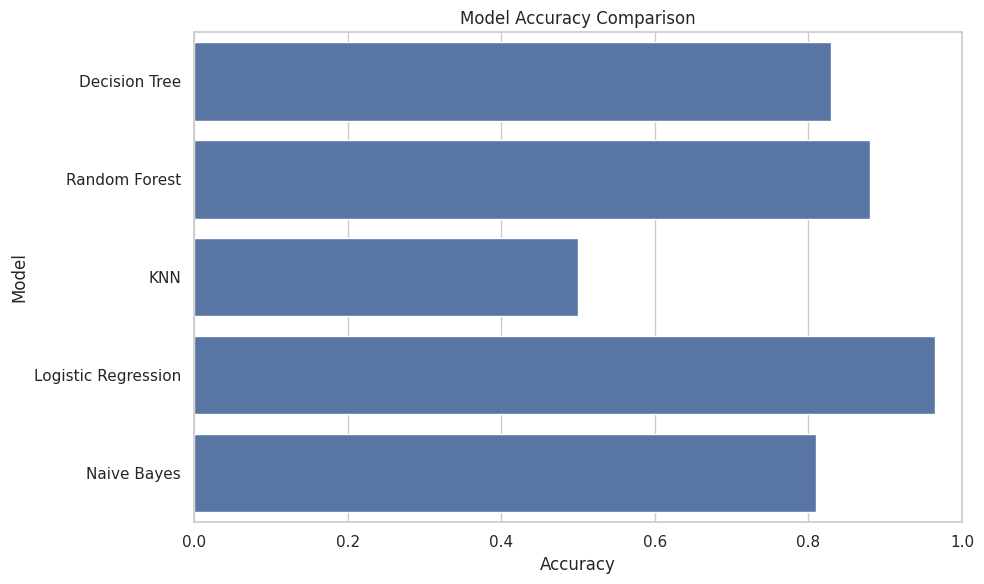

In [30]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create the folder if it doesn't exist
os.makedirs("../images/comparison", exist_ok=True)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_accuracy,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    "../images/comparison/model_accuracy_comparison.png",
    dpi=300
)

plt.show()

In [26]:
def evaluate_model(model_name, y_true, y_pred):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [27]:
results = []

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "KNN",
        y_test,
        knn_pred
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        nb_pred
    )
)

In [28]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Logistic Regression,0.965,0.965045,0.965,0.964986
1,Random Forest,0.880,0.879647,0.880,0.879688
0,Decision Tree,0.830,0.832745,0.830,0.830948
4,Naive Bayes,0.810,0.811326,0.810,0.810458
2,KNN,0.500,0.521130,0.500,0.505355


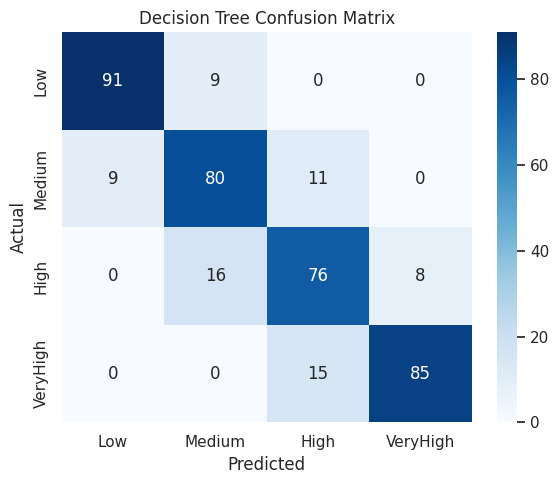

In [31]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create folder if it doesn't exist
os.makedirs("../images/confusion_matrix", exist_ok=True)

# Calculate confusion matrix
cm_dt = confusion_matrix(
    y_test,
    dt_pred
)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High", "VeryHigh"],
    yticklabels=["Low", "Medium", "High", "VeryHigh"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save
plt.savefig(
    "../images/confusion_matrix/decision_tree.png",
    dpi=300
)

plt.show()

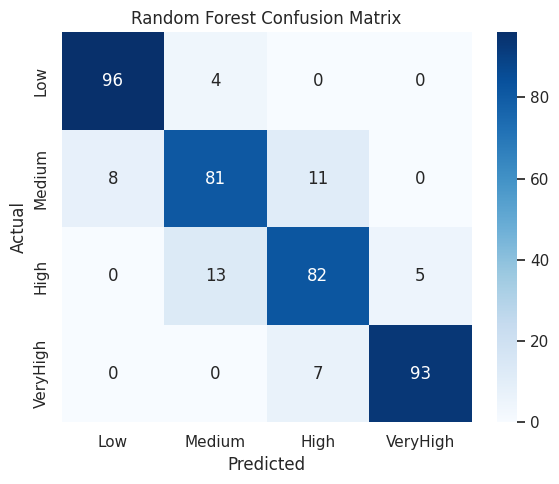

In [32]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

os.makedirs("../images/confusion_matrix", exist_ok=True)

cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High", "VeryHigh"],
    yticklabels=["Low", "Medium", "High", "VeryHigh"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix/random_forest.png",
    dpi=300
)

plt.show()

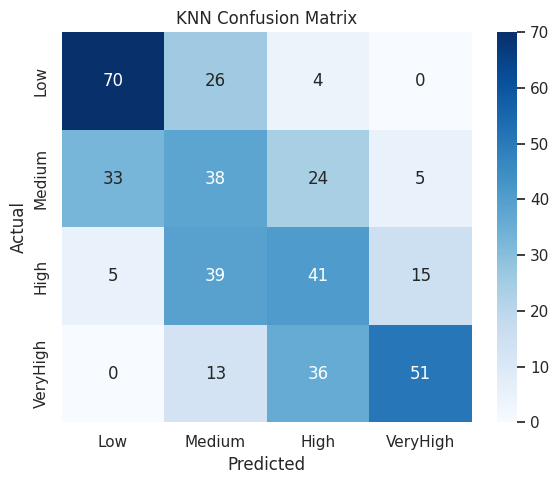

In [33]:
cm_knn = confusion_matrix(
    y_test,
    knn_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High", "VeryHigh"],
    yticklabels=["Low", "Medium", "High", "VeryHigh"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix/knn.png",
    dpi=300
)

plt.show()

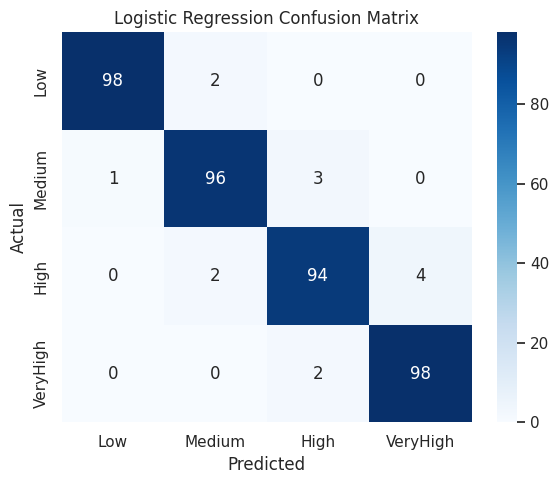

In [34]:
cm_lr = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High", "VeryHigh"],
    yticklabels=["Low", "Medium", "High", "VeryHigh"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix/logistic_regression.png",
    dpi=300
)

plt.show()

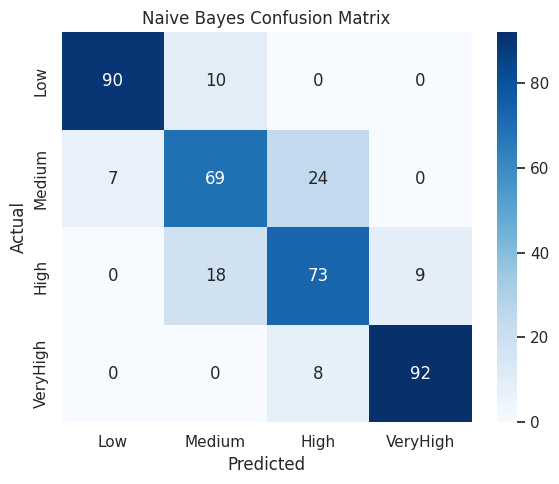

In [35]:
cm_nb = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High", "VeryHigh"],
    yticklabels=["Low", "Medium", "High", "VeryHigh"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix/naive_bayes.png",
    dpi=300
)

plt.show()

In [36]:
print("===== DECISION TREE =====")
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Low", "Medium", "High", "VeryHigh"]
))

print("===== RANDOM FOREST =====")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Low", "Medium", "High", "VeryHigh"]
))

print("===== KNN =====")
print(classification_report(
    y_test,
    knn_pred,
    target_names=["Low", "Medium", "High", "VeryHigh"]
))

print("===== LOGISTIC REGRESSION =====")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Low", "Medium", "High", "VeryHigh"]
))

print("===== NAIVE BAYES =====")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Low", "Medium", "High", "VeryHigh"]
))

===== DECISION TREE =====
              precision    recall  f1-score   support

         Low       0.91      0.91      0.91       100
      Medium       0.76      0.80      0.78       100
        High       0.75      0.76      0.75       100
    VeryHigh       0.91      0.85      0.88       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400

===== RANDOM FOREST =====
              precision    recall  f1-score   support

         Low       0.92      0.96      0.94       100
      Medium       0.83      0.81      0.82       100
        High       0.82      0.82      0.82       100
    VeryHigh       0.95      0.93      0.94       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400

===== KNN =====
              precision    recall  f1-score   support

       

In [37]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.965,0.9650,0.965,0.9650
1,Random Forest,0.880,0.8796,0.880,0.8797
2,Decision Tree,0.830,0.8327,0.830,0.8309
3,Naive Bayes,0.810,0.8113,0.810,0.8105
4,KNN,0.500,0.5211,0.500,0.5054


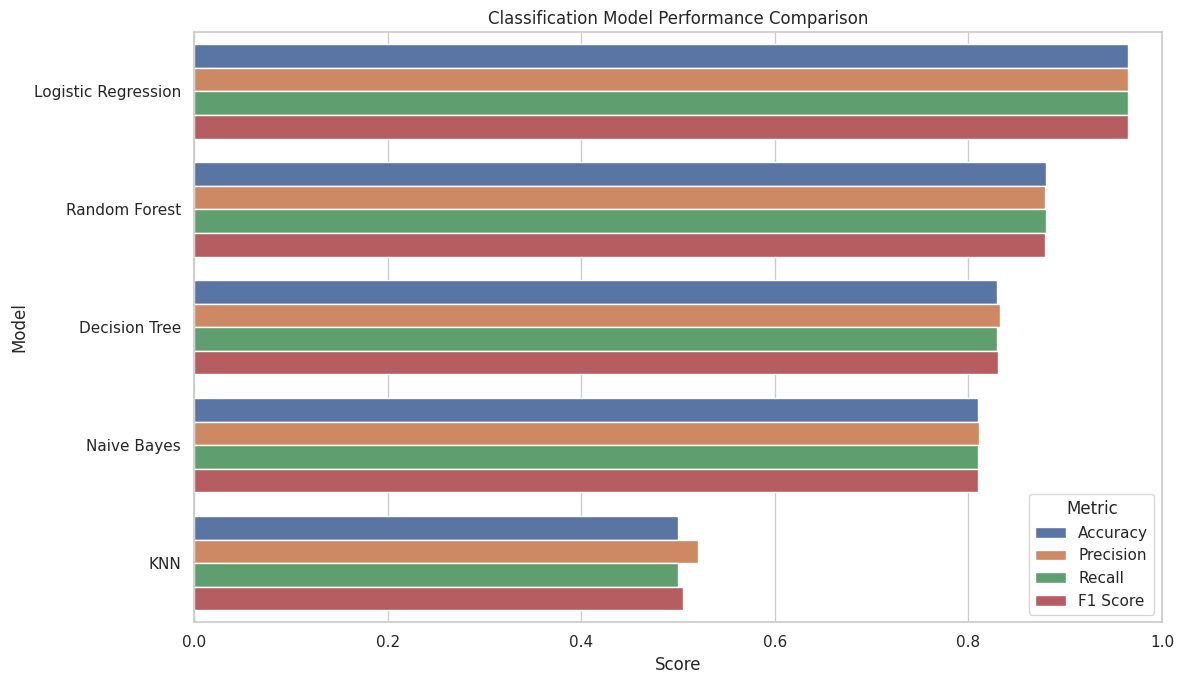

In [38]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

metrics_long = results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=metrics_long,
    x="Score",
    y="Model",
    hue="Metric"
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    "../images/comparison/classification_metrics_comparison.png",
    dpi=300
)

plt.show()

In [39]:
best_model_row = results_df.iloc[0]

print("Best Model:", best_model_row["Model"])
print("Accuracy:", round(best_model_row["Accuracy"], 4))
print("Precision:", round(best_model_row["Precision"], 4))
print("Recall:", round(best_model_row["Recall"], 4))
print("F1 Score:", round(best_model_row["F1 Score"], 4))

Best Model: Logistic Regression
Accuracy: 0.965
Precision: 0.965
Recall: 0.965
F1 Score: 0.965


In [40]:
import os

os.makedirs("../data/processed", exist_ok=True)

results_df.round(4).to_csv(
    "../data/processed/classification_model_results.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [41]:
reports = {}

model_predictions = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred
}

for model_name, predictions in model_predictions.items():
    reports[model_name] = classification_report(
        y_test,
        predictions,
        target_names=["Low", "Medium", "High", "VeryHigh"]
    )

for model_name, report in reports.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(report)

Decision Tree
              precision    recall  f1-score   support

         Low       0.91      0.91      0.91       100
      Medium       0.76      0.80      0.78       100
        High       0.75      0.76      0.75       100
    VeryHigh       0.91      0.85      0.88       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400

Random Forest
              precision    recall  f1-score   support

         Low       0.92      0.96      0.94       100
      Medium       0.83      0.81      0.82       100
        High       0.82      0.82      0.82       100
    VeryHigh       0.95      0.93      0.94       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400

KNN
              precision    recall  f1-score   support

         Low       0.65      0.70      0.67

## Task 7 - Conclusion

Five machine learning classification algorithms were implemented to predict mobile phone price ranges:

1. Decision Tree
2. Random Forest
3. K-Nearest Neighbors
4. Logistic Regression
5. Naive Bayes

The models were evaluated using Accuracy, Precision, Recall, and F1-score. Confusion matrices and classification reports were also generated for detailed evaluation.

The models showed different levels of predictive performance. The best-performing model was selected based on the F1-score obtained on the test dataset.

The results demonstrate that machine learning can effectively classify mobile phones into Low, Medium, High, and VeryHigh price categories based on their specifications.

## Best Model

The model with the highest F1-score was selected as the best-performing classification model.

The selected model will be further optimized in **Task 8** using hyperparameter tuning to improve its performance and identify the optimal configuration.